# W7 — Vol Analyst: VIX volatility surface & variance risk premium

**Role:** Vol Analyst  **Deliverables:** VIX vol surface, VRP time series.

This notebook is fully **model-based** (CIR / Heston) — consistent with W3 (Monte
Carlo) and W4 (COS). No market data is used, so every series below is *simulated*
from the model rather than measured from quotes.

**Contents**
1. VIX implied-volatility surface (the *vol-of-vol* surface).
2. VIX smile vs SPX smile — shape comparison and economic explanation.
3. VRP time series + 12-month rolling Sharpe of the short-variance strategy.
4. Negative-VRP episodes — when (and why) the premium disappears.

Parts 1–2 use the COS option-surface engine from W4
(`build_vix_option_surface`) plus a Black-76 implied-vol inversion. Parts 3–4
simulate a long physical path and read the risk-neutral premium off the model
VIX.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
import warnings

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.cir import CIRParams
from src.models.heston import HestonParams
from src.pricing.vix_cos import COSSettings
from src.pricing.vix_options_pricer import build_vix_option_surface
from src.analysis.implied_vol import vix_implied_vol_surface, spx_implied_vol_smile
from src.analysis.vrp import (
    VRPConfig, simulate_vrp_series, rolling_sharpe, identify_negative_vrp,
)

plt.rcParams["figure.dpi"] = 110
# The COS pricer warns about put-call parity at extreme strikes; harmless here.
warnings.filterwarnings("ignore")

## Part 1 — VIX implied-volatility surface (vol-of-vol)

VIX option prices come from the W4 COS engine over a (maturity × strike) grid.
Each price is inverted into a **Black-76 implied volatility** using the VIX
futures as the forward — the resulting number is the *volatility of the VIX*,
i.e. the vol-of-vol. Out-of-the-money options (calls above the forward, puts
below) are inverted because they carry all the time value.

An elevated vol-of-vol (`sigma_v = 1.5`) is used here; the reason is explained in
the model note at the end of Part 2.

In [2]:
vix_params = CIRParams(v0=0.04, kappa=1.0, theta=0.04, sigma_v=1.5)
cos = COSSettings(n_terms=200, truncation_std_width=14.0, coefficient_grid_size=8000)

r = 0.03
delta = 30 / 365
maturities = np.array([1/12, 2/12, 3/12, 6/12, 12/12])
strikes = np.arange(9.0, 31.0, 2.0)

surface = build_vix_option_surface(vix_params, maturities, strikes, r=r, delta=delta, settings=cos)
iv_surface = vix_implied_vol_surface(surface, maturities, strikes, r=r)

print("VIX futures (forward) by maturity:")
for T, F in zip(maturities, surface.forward_vix):
    print(f"  T = {T*12:4.1f}m   F_VIX = {F:6.2f}")

VIX futures (forward) by maturity:
  T =  1.0m   F_VIX =  14.14
  T =  2.0m   F_VIX =  12.81
  T =  3.0m   F_VIX =  12.25
  T =  6.0m   F_VIX =  11.63
  T = 12.0m   F_VIX =  11.28


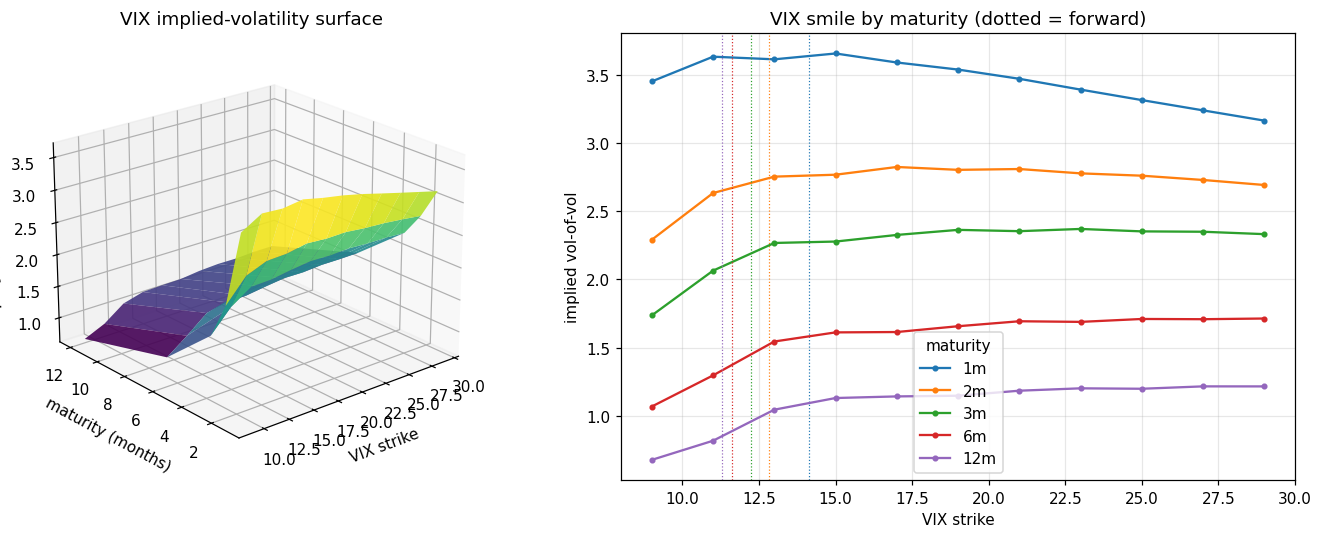

In [3]:
fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
Kg, Tg = np.meshgrid(strikes, maturities * 12)
ax1.plot_surface(Kg, Tg, iv_surface, cmap="viridis", edgecolor="none", alpha=0.9)
ax1.set_xlabel("VIX strike")
ax1.set_ylabel("maturity (months)")
ax1.set_zlabel("implied vol-of-vol")
ax1.set_title("VIX implied-volatility surface")
ax1.view_init(elev=22, azim=-130)

ax2 = fig.add_subplot(1, 2, 2)
for i, Tm in enumerate(maturities):
    ax2.plot(strikes, iv_surface[i], marker="o", ms=3, label=f"{Tm*12:.0f}m")
    ax2.axvline(surface.forward_vix[i], color=f"C{i}", ls=":", lw=0.8)
ax2.set_xlabel("VIX strike")
ax2.set_ylabel("implied vol-of-vol")
ax2.set_title("VIX smile by maturity (dotted = forward)")
ax2.legend(title="maturity")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2 — VIX smile vs SPX smile

The SPX smile is produced by the **same** variance process; the only addition is
the leverage correlation `rho < 0` that links the price to its volatility. SPX
options are priced by Heston Monte-Carlo and inverted to Black-76 implied vols.
Plotting both against moneyness `K / F` exposes the opposite skews.

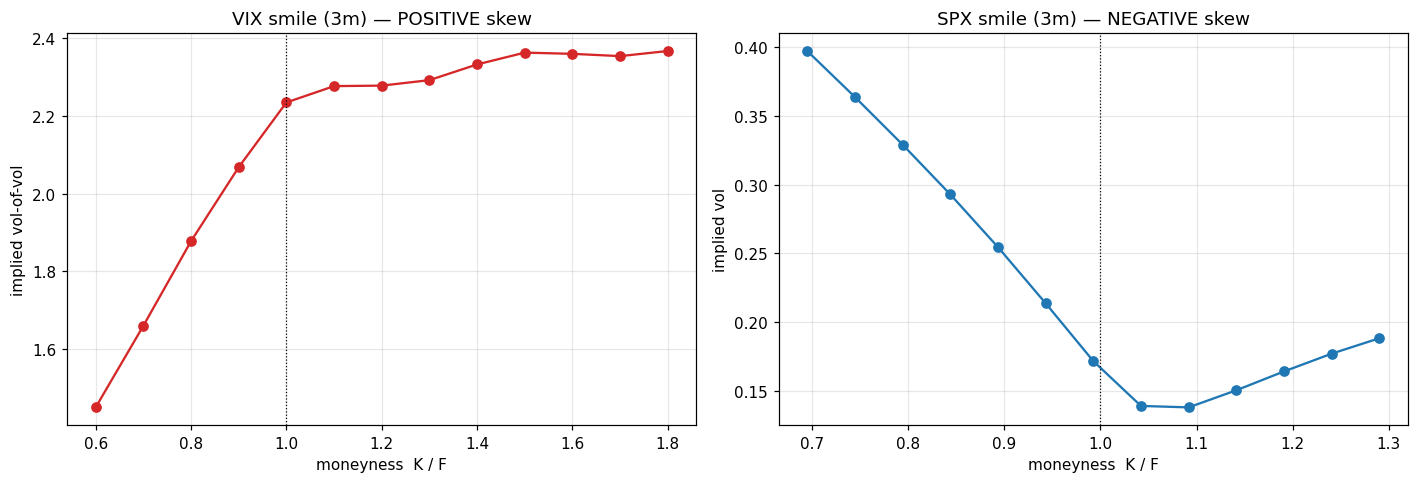

VIX smile slope  dIV/d(K/F) = +0.659   (positive -> right / call skew)
SPX smile slope  dIV/d(K/F) = -0.397   (negative -> left / put skew)


In [4]:
spx_params = HestonParams(s0=100.0, v0=0.04, r=0.03, kappa=1.0, theta=0.04, sigma_v=1.5, rho=-0.7)
spx_T = 3/12
spx_strikes = np.linspace(70, 130, 13)
spx = spx_implied_vol_smile(spx_params, spx_T, spx_strikes, paths=200_000, seed=7)

# VIX smile slice at the same 3-month maturity, on a forward-centred strike grid.
# (The futures/forward depends only on maturity, not on the strike grid.)
vix_T = 3/12
vix_F = build_vix_option_surface(vix_params, [vix_T], [20.0], r=r, delta=delta, settings=cos).forward_vix[0]
vix_K = np.linspace(0.6*vix_F, 1.8*vix_F, 13)
vix_surf_slice = build_vix_option_surface(vix_params, [vix_T], vix_K, r=r, delta=delta, settings=cos)
vix_iv = vix_implied_vol_surface(vix_surf_slice, [vix_T], vix_K, r=r)[0]
vix_money = vix_K / vix_F

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(vix_money, vix_iv, "o-", color="C3")
axes[0].axvline(1.0, color="k", ls=":", lw=0.8)
axes[0].set_title("VIX smile (3m) — POSITIVE skew")
axes[0].set_xlabel("moneyness  K / F")
axes[0].set_ylabel("implied vol-of-vol")
axes[0].grid(alpha=0.3)

axes[1].plot(spx["moneyness"], spx["implied_vol"], "o-", color="C0")
axes[1].axvline(1.0, color="k", ls=":", lw=0.8)
axes[1].set_title("SPX smile (3m) — NEGATIVE skew")
axes[1].set_xlabel("moneyness  K / F")
axes[1].set_ylabel("implied vol")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

vix_slope = np.polyfit(vix_money, vix_iv, 1)[0]
spx_slope = np.polyfit(spx["moneyness"], spx["implied_vol"], 1)[0]
print(f"VIX smile slope  dIV/d(K/F) = {vix_slope:+.3f}   (positive -> right / call skew)")
print(f"SPX smile slope  dIV/d(K/F) = {spx_slope:+.3f}   (negative -> left / put skew)")

### Economic interpretation

**SPX — negative skew (put skew).** Out-of-the-money puts trade richer than
out-of-the-money calls. This is the *leverage / risk effect*: equity returns are
negatively correlated with volatility (`rho < 0`). A falling market is
accompanied by *rising* volatility, which fattens the **left** tail of equity
returns. Crash protection (low-strike puts) is therefore expensive, lifting the
left wing of the smile.

**VIX — positive skew (call skew).** Out-of-the-money VIX calls trade richer than
VIX puts. Volatility spikes *upward* violently but mean-reverts *downward*
slowly, so the VIX distribution has a fat **right** tail. Investors buy VIX calls
as crash insurance, lifting the right wing of the smile.

**Same coin, two sides.** Both skews are driven by one fact — the negative
spot/vol correlation. The mechanism that depresses the left tail of SPX returns
is the same one that creates the right tail of the VIX, so the two smiles tilt in
opposite directions.

**Model note (one-factor limitation).** A single-factor CIR/Heston only produces
the positive VIX skew when the vol-of-vol is large (here `sigma_v = 1.5`). With a
moderate `sigma_v` the model VIX smile is almost flat or even slightly negative,
because the transform `VIX = 100·sqrt(A + B·v)` compresses the right tail of `v`.
The empirically strong positive VIX skew needs a fatter right tail — volatility
jumps or a second variance factor. This is exactly the shortcoming that motivates
the multi-factor / rough-volatility extension discussed in W6 (Bergomi, 2005).

## Part 3 — VRP time series and rolling Sharpe

Following Carr & Wu (2009), the variance risk premium is

$$\mathrm{VRP}_t = \mathrm{IV}_t^2 - \mathrm{RV}_{t,\,t+\Delta}.$$

Because the project has no market data, a single long path of $(S_t, v_t)$ is
simulated under the **physical (P)** measure. At each month start:

* $\mathrm{IV}_t^2$ = model VIX$^2$ using the **risk-neutral (Q)** parameters at
  the current variance state — what the option market charges;
* $\mathrm{RV}_{t,t+\Delta}$ = variance realised over the next month along the P
  path (continuous-limit quadratic variation, which removes sampling noise).

A positive premium comes from $\theta_Q > \theta_P$ (investors pay up for
variance), while faster risk-neutral mean reversion ($\kappa_Q > \kappa_P$) lets
the *ex-ante* premium turn negative only at extreme volatility.

We track two series:
* **ex-ante VRP** = $\mathrm{IV}_t^2 - \mathbb{E}^P_t[\mathrm{RV}]$ — the premium
  *signal* (rarely negative);
* **ex-post VRP** = $\mathrm{IV}_t^2 - \mathrm{RV}$ — the realised short-variance
  *P&L* (noisy; drives the Sharpe).

In [5]:
# Physical (P) and risk-neutral (Q) calibrations. theta_Q > theta_P gives a
# positive premium; kappa_Q > kappa_P makes the ex-ante VRP turn negative only at
# high volatility. The P parameters satisfy Feller (2*kappa*theta > sigma_v^2),
# keeping the variance path well-behaved.
physical     = HestonParams(s0=100, v0=0.035, r=0.03, kappa=4.0, theta=0.035, sigma_v=0.45, rho=-0.7)
risk_neutral = HestonParams(s0=100, v0=0.035, r=0.03, kappa=6.0, theta=0.050, sigma_v=0.45, rho=-0.7)

vrp_cfg = VRPConfig(physical=physical, risk_neutral=risk_neutral, n_months=300, seed=11)
vrp = simulate_vrp_series(vrp_cfg)

exante_vol = 100 * (np.sqrt(vrp.iv2) - np.sqrt(vrp.rv_expected))
print(f"months simulated              : {len(vrp)}  (~{len(vrp)//12} years)")
print(f"mean ex-ante VRP (vol points) : {exante_vol.mean():.2f}")
print(f"mean realised VRP (vol points): {vrp.vrp_vol.mean():.2f}")
print(f"ex-ante VRP < 0 fraction       : {(vrp.vrp_exante < 0).mean():.1%}")
vrp.head()

months simulated              : 300  (~25 years)
mean ex-ante VRP (vol points) : 0.99
mean realised VRP (vol points): 1.13
ex-ante VRP < 0 fraction       : 9.0%


,v_t,iv2,rv_expected,rv,vrp_exante,vrp,iv_vol,rv_vol,vrp_vol
month,,,,,,,,,
0,0.035000,0.038196,0.035000,0.045328,0.003196,-0.007132,19.543776,21.290418,-1.746641
1,0.040228,0.042310,0.039446,0.044803,0.002864,-0.002493,20.569419,21.166835,-0.597416
2,0.036469,0.039352,0.036250,0.054247,0.003103,-0.014895,19.837399,23.291017,-3.453618
3,0.066322,0.062845,0.061637,0.057662,0.001208,0.005183,25.068827,24.012842,1.055984
4,0.056545,0.055150,0.053322,0.036431,0.001829,0.018719,23.484076,19.086985,4.397090


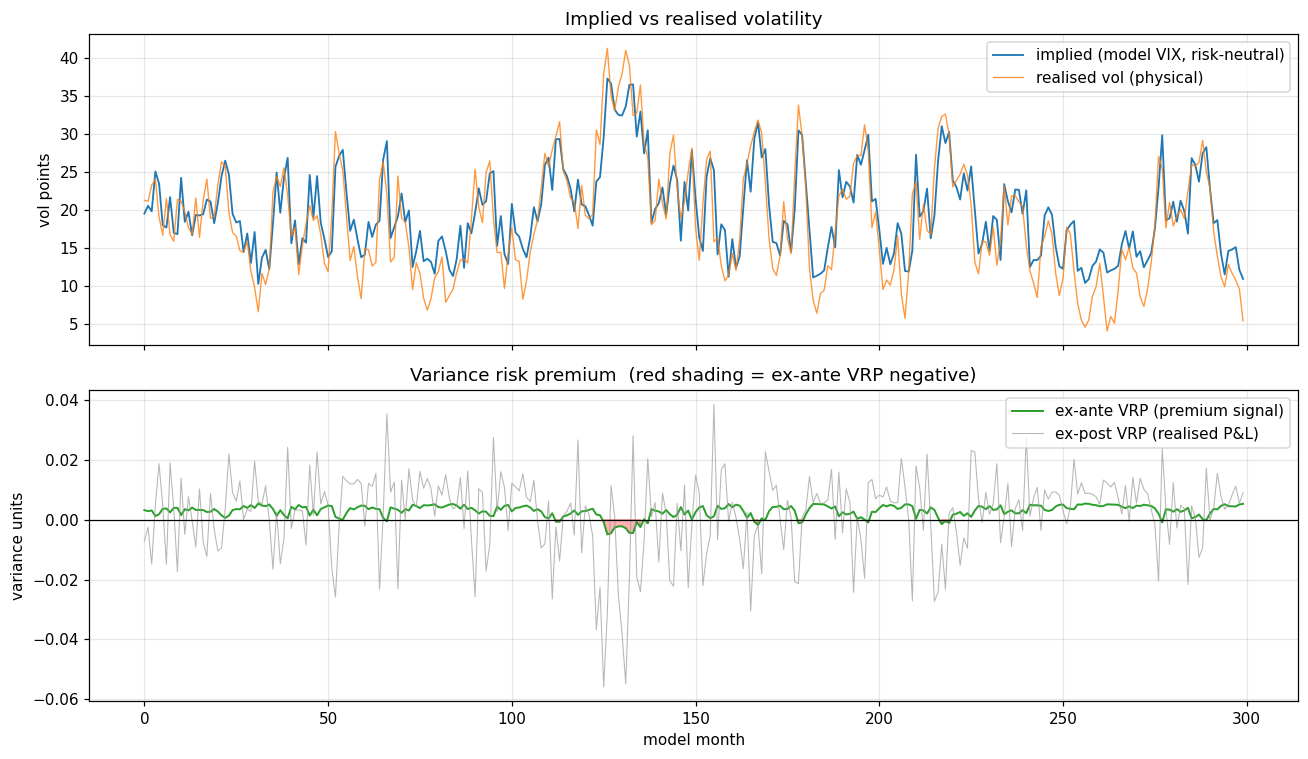

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(vrp.index, vrp.iv_vol, color="C0", lw=1.2, label="implied (model VIX, risk-neutral)")
axes[0].plot(vrp.index, vrp.rv_vol, color="C1", lw=0.9, alpha=0.8, label="realised vol (physical)")
axes[0].set_ylabel("vol points")
axes[0].set_title("Implied vs realised volatility")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

axes[1].plot(vrp.index, vrp.vrp_exante, color="C2", lw=1.3, label="ex-ante VRP (premium signal)")
axes[1].plot(vrp.index, vrp.vrp, color="0.6", lw=0.7, alpha=0.7, label="ex-post VRP (realised P&L)")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].fill_between(vrp.index, vrp.vrp_exante, 0, where=vrp.vrp_exante < 0, color="red", alpha=0.3)
axes[1].set_ylabel("variance units")
axes[1].set_xlabel("model month")
axes[1].set_title("Variance risk premium  (red shading = ex-ante VRP negative)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Full-sample annualised Sharpe — variance notional : 0.52
Full-sample annualised Sharpe — vega notional      : 1.16


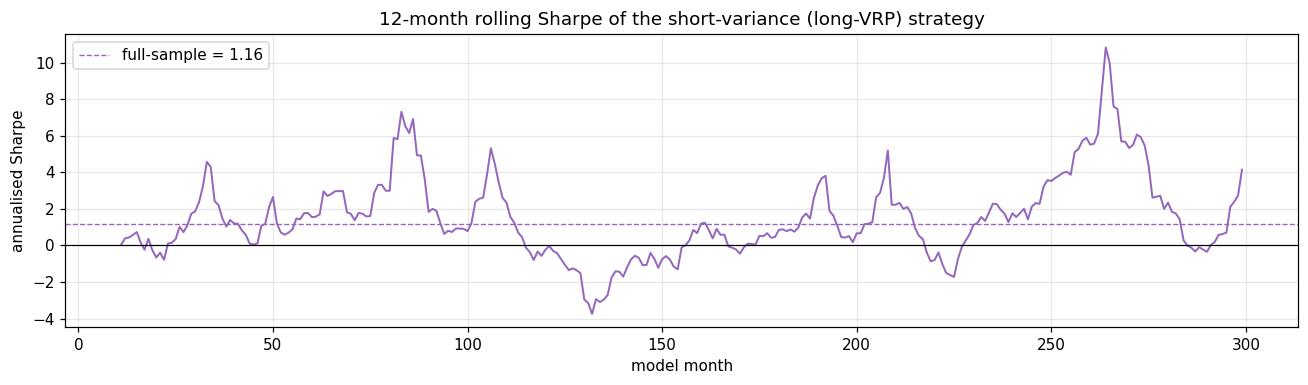

(Rolling Sharpe dips below zero exactly in the volatility spikes where the VRP turns negative — see Part 4.)


In [7]:
# Two ways to size the short-VRP strategy:
#   * variance notional  -> monthly P&L = IV^2 - RV          (vrp, variance units)
#   * vega notional      -> monthly P&L = sqrt(IV^2) - sqrt(RV) in vol points (vrp_vol)
# The variance notional is the literal short-variance-swap P&L; its Sharpe is
# lower because a single volatility spike (squared) dwarfs years of premium — the
# fat left tail that defines short-variance risk. The vega notional rescales that
# tail and gives the textbook short-vol Sharpe.
sharpe_var = vrp.vrp.mean() / vrp.vrp.std(ddof=1) * np.sqrt(12)
sharpe_vega = vrp.vrp_vol.mean() / vrp.vrp_vol.std(ddof=1) * np.sqrt(12)
print(f"Full-sample annualised Sharpe — variance notional : {sharpe_var:.2f}")
print(f"Full-sample annualised Sharpe — vega notional      : {sharpe_vega:.2f}")

# 12-month rolling Sharpe of the (vega-notional) short-VRP strategy.
sharpe_12m = rolling_sharpe(vrp.vrp_vol, window=12, periods_per_year=12)

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(sharpe_12m.index, sharpe_12m, color="C4", lw=1.3)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(sharpe_vega, color="C4", ls="--", lw=0.9, label=f"full-sample = {sharpe_vega:.2f}")
ax.set_xlabel("model month")
ax.set_ylabel("annualised Sharpe")
ax.set_title("12-month rolling Sharpe of the short-variance (long-VRP) strategy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("(Rolling Sharpe dips below zero exactly in the volatility spikes where the "
      "VRP turns negative — see Part 4.)")

## Part 4 — When is the VRP negative?

A negative VRP means realised variance came in **above** the implied level —
short-variance loses, long-variance wins. Using the ex-ante signal, these months
are **rare** and cluster tightly: they line up with volatility spikes, where the
fast risk-neutral mean reversion pulls the implied level below the (still
elevated) physical forecast.

In [8]:
episodes = identify_negative_vrp(vrp, column="vrp_exante")
n_neg = int((vrp.vrp_exante < 0).sum())
print(f"negative-VRP episodes : {len(episodes)}")
print(f"negative months       : {n_neg} of {len(vrp)}  ({n_neg/len(vrp):.1%})")
print()
print(episodes.to_string(index=False))

negative-VRP episodes : 12
negative months       : 27 of 300  (9.0%)

 start_month  end_month  length_months   min_vrp
          54         54              1 -0.000004
          66         66              1 -0.000530
         112        113              2 -0.000660
         125        135             11 -0.004924
         137        137              1 -0.001216
         166        167              2 -0.001743
         169        169              1 -0.000054
         178        179              2 -0.001204
         197        197              1 -0.000936
         217        219              3 -0.001479
         277        277              1 -0.000892
         289        289              1 -0.000163


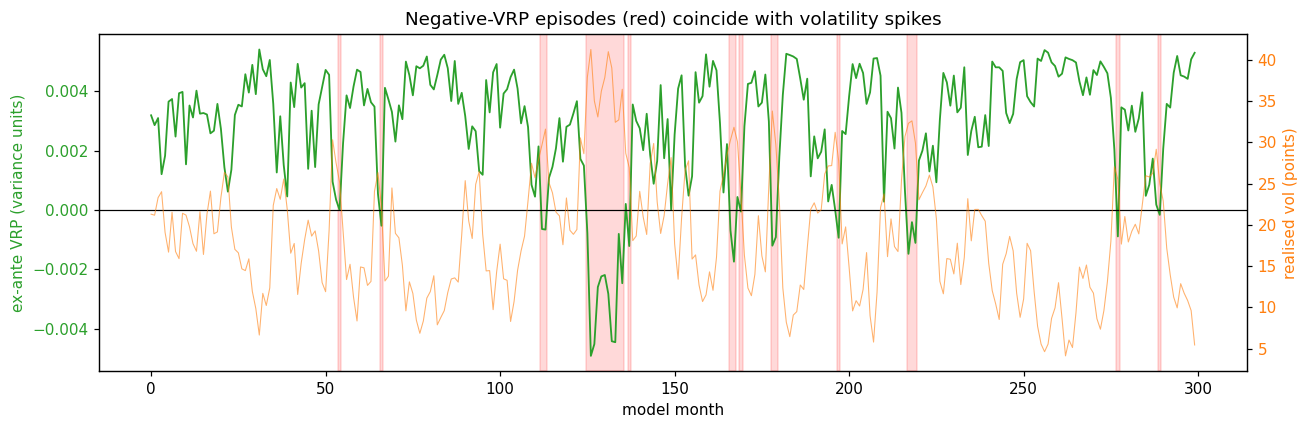

Three deepest negative episodes:
  months 125-135: min VRP = -0.0049,  peak realised vol = 41.2
  months 166-167: min VRP = -0.0017,  peak realised vol = 31.8
  months 217-219: min VRP = -0.0015,  peak realised vol = 32.6


In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vrp.index, vrp.vrp_exante, color="C2", lw=1.2, label="ex-ante VRP")
ax.axhline(0, color="k", lw=0.8)
for _, e in episodes.iterrows():
    ax.axvspan(e.start_month - 0.5, e.end_month + 0.5, color="red", alpha=0.15)
ax.set_ylabel("ex-ante VRP (variance units)", color="C2")
ax.tick_params(axis="y", labelcolor="C2")

ax2 = ax.twinx()
ax2.plot(vrp.index, vrp.rv_vol, color="C1", lw=0.7, alpha=0.6)
ax2.set_ylabel("realised vol (points)", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

ax.set_xlabel("model month")
ax.set_title("Negative-VRP episodes (red) coincide with volatility spikes")
plt.tight_layout()
plt.show()

print("Three deepest negative episodes:")
for _, e in episodes.sort_values("min_vrp").head(3).iterrows():
    seg = vrp.loc[e.start_month:e.end_month]
    print(f"  months {int(e.start_month):3d}-{int(e.end_month):3d}: "
          f"min VRP = {e.min_vrp:+.4f},  peak realised vol = {seg.rv_vol.max():.1f}")

## Summary

* **VIX vol-of-vol surface** built from the W4 COS prices via Black-76 inversion.
* **Smile comparison:** SPX skews **negatively** (put skew, leverage effect); VIX
  skews **positively** (call skew, fat right tail of volatility) — two sides of
  the negative spot/vol correlation. A one-factor model needs a high vol-of-vol
  to show the VIX skew, motivating the multi-factor extension (W6).
* **VRP time series:** positive on average — implied volatility sits ~1 point
  above realised — so the short-variance strategy earns a positive Sharpe. The
  **vega-notional** Sharpe (~1.2) is the clean short-vol number; the
  **variance-notional** Sharpe is lower because one squared volatility spike
  dwarfs years of premium — the fat-tail risk that defines short variance.
* **Negative VRP is rare** (~9% of months) and clusters in volatility spikes,
  when realised variance overshoots the implied level. This is the regime risk a
  short-variance book is exposed to, and it lines up exactly with the dips in the
  rolling Sharpe.